In [1]:
# 1. Load data

import pandas as pd
import numpy as np

PARQUET_PATH = "../data/Merged/final_merged_panel.parquet"

df = pd.read_parquet(PARQUET_PATH)

print(df.shape)
print(df.columns.tolist())
df.head()

(12715, 48)
['country', 'year', 'wb_current_account_pct_gdp', 'wb_exports_pct_gdp', 'wb_gdp_growth', 'wb_gov_consumption_pct_gdp', 'wb_imports_pct_gdp', 'wb_inflation_cpi', 'imf_inflation_imf', 'oecd_business_confidence_oecd', 'oecd_cli_growth_oecd', 'oecd_cli_level_oecd', 'oecd_consumer_confidence_oecd', 'non_null_feature_count', 'feature_coverage_pct', 'wb_current_account_pct_gdp_lag1', 'wb_current_account_pct_gdp_lag2', 'wb_exports_pct_gdp_lag1', 'wb_exports_pct_gdp_lag2', 'wb_gdp_growth_lag1', 'wb_gdp_growth_lag2', 'wb_gov_consumption_pct_gdp_lag1', 'wb_gov_consumption_pct_gdp_lag2', 'wb_imports_pct_gdp_lag1', 'wb_imports_pct_gdp_lag2', 'wb_inflation_cpi_lag1', 'wb_inflation_cpi_lag2', 'imf_inflation_imf_lag1', 'imf_inflation_imf_lag2', 'oecd_business_confidence_oecd_lag1', 'oecd_business_confidence_oecd_lag2', 'oecd_cli_growth_oecd_lag1', 'oecd_cli_growth_oecd_lag2', 'oecd_cli_level_oecd_lag1', 'oecd_cli_level_oecd_lag2', 'oecd_consumer_confidence_oecd_lag1', 'oecd_consumer_confid

,country,year,wb_current_account_pct_gdp,wb_exports_pct_gdp,wb_gdp_growth,wb_gov_consumption_pct_gdp,wb_imports_pct_gdp,wb_inflation_cpi,imf_inflation_imf,oecd_business_confidence_oecd,...,wb_exports_pct_gdp_chg1,wb_gdp_growth_chg1,wb_gov_consumption_pct_gdp_chg1,wb_imports_pct_gdp_chg1,wb_inflation_cpi_chg1,imf_inflation_imf_chg1,oecd_business_confidence_oecd_chg1,oecd_cli_growth_oecd_chg1,oecd_cli_level_oecd_chg1,oecd_consumer_confidence_oecd_chg1
0,Afghanistan,2002,-2.35799,10.420817,28.600001,22.109219,36.289077,12.686269,37.07650,100.0669,...,0.0,-19.767723,0.0,0.0,0.000000,-4.50225,0.0,0.0,0.0,0.0
1,Afghanistan,2003,-2.35799,10.420817,8.832278,22.109219,36.289077,12.686269,32.57425,100.0669,...,0.0,-19.767723,0.0,0.0,0.000000,-4.50225,0.0,0.0,0.0,0.0
2,Afghanistan,2004,-2.35799,10.420817,1.414118,22.109219,36.289077,12.686269,32.68175,100.0669,...,0.0,-7.418160,0.0,0.0,0.000000,0.10750,0.0,0.0,0.0,0.0
3,Afghanistan,2005,-2.35799,10.420817,11.229715,22.109219,36.289077,12.686269,33.22900,100.0669,...,0.0,9.815597,0.0,0.0,0.000000,0.54725,0.0,0.0,0.0,0.0
4,Afghanistan,2006,-2.35799,10.420817,5.357403,22.109219,36.289077,6.784597,32.25250,100.0669,...,0.0,-5.872312,0.0,0.0,-5.901672,-0.97650,0.0,0.0,0.0,0.0


In [ ]:
# Fix country names

# Step 1: Clean country names and drop aggregate entities

world_bank = df.copy()

# Standardize country spelling variants
country_name_map = {
    "Vietnam": "Viet Nam",
    "Türkiye, Republic of": "Turkiye",
    "Aruba, Kingdom of the Netherlands": "Aruba",
    "Bahrain, Kingdom of": "Bahrain",
    "Croatia, Republic of": "Croatia",
    "Estonia, Republic of": "Estonia",
    "Latvia, Republic of": "Latvia",
    "Lithuania, Republic of": "Lithuania",
    "Netherlands, The": "Netherlands",
    "Poland, Republic of": "Poland",
    "San Marino, Republic of": "San Marino",
    "Slovenia, Republic of": "Slovenia",
    "Armenia, Republic of": "Armenia",
    "Azerbaijan, Republic of": "Azerbaijan",
    "Belarus, Republic of": "Belarus",
    "Fiji, Republic of": "Fiji",
    "Kazakhstan, Republic of": "Kazakhstan",
    "Kosovo, Republic of": "Kosovo",
    "Moldova, Republic of": "Moldova",
    "North Macedonia, Republic of": "North Macedonia",
    "Serbia, Republic of": "Serbia",
    "Uzbekistan, Republic of": "Uzbekistan",
    "Syrian Arab Republic": "Syria Arab Republic",
    "Puerto Rico (US)": "Puerto Rico",
}

world_bank["country"] = world_bank["country"].replace(country_name_map)

# Drop aggregate/regional entities
aggregates = [
    "Africa Western and Central",
    "Caribbean small states",
    "Early-demographic dividend",
    "Heavily indebted poor countries (HIPC)",
    "Late-demographic dividend",
    "Least developed countries: UN classification",
    "North America",
    "OECD members",
    "Pacific island small states",
    "Post-demographic dividend",
    "Pre-demographic dividend",
]

before_shape = world_bank.shape

world_bank = world_bank[~world_bank["country"].isin(aggregates)].copy()

print("Before:", before_shape)
print("After:", world_bank.shape)

print("\nCountries containing Viet:")
print(
    world_bank[world_bank["country"].str.contains("Viet", case=False, na=False)][
        "country"
    ].value_counts()
)

Before: (12715, 48)
After: (12129, 48)

Countries containing Viet:
country
Viet Nam    80
Name: count, dtype: int64


In [ ]:
# 2. Target Construction

world_bank = world_bank.sort_values(["country", "year"]).reset_index(drop=True)

# Get next year's GDP growth within each country
world_bank["gdp_growth_next_year"] = world_bank.groupby("country")[
    "wb_gdp_growth"
].shift(-1)

# Define target only where next year's GDP growth exists
world_bank["recession_next_year"] = np.where(
    world_bank["gdp_growth_next_year"].isna(),
    np.nan,
    (world_bank["gdp_growth_next_year"] < 0).astype(int),
)

# Drop rows where target cannot be observed
world_bank = world_bank.dropna(subset=["recession_next_year"]).copy()
world_bank["recession_next_year"] = world_bank["recession_next_year"].astype(int)

print(f"Dataset: {world_bank.shape}")
print(f"Positive class rate: {world_bank['recession_next_year'].mean():.1%}")

print("\nTarget counts:")
print(world_bank["recession_next_year"].value_counts())

Dataset: (11914, 50)
Positive class rate: 15.7%

Target counts:
recession_next_year
0    10043
1     1871
Name: count, dtype: int64


In [4]:
world_bank.columns

Index(['country', 'year', 'wb_current_account_pct_gdp', 'wb_exports_pct_gdp',
       'wb_gdp_growth', 'wb_gov_consumption_pct_gdp', 'wb_imports_pct_gdp',
       'wb_inflation_cpi', 'imf_inflation_imf',
       'oecd_business_confidence_oecd', 'oecd_cli_growth_oecd',
       'oecd_cli_level_oecd', 'oecd_consumer_confidence_oecd',
       'non_null_feature_count', 'feature_coverage_pct',
       'wb_current_account_pct_gdp_lag1', 'wb_current_account_pct_gdp_lag2',
       'wb_exports_pct_gdp_lag1', 'wb_exports_pct_gdp_lag2',
       'wb_gdp_growth_lag1', 'wb_gdp_growth_lag2',
       'wb_gov_consumption_pct_gdp_lag1', 'wb_gov_consumption_pct_gdp_lag2',
       'wb_imports_pct_gdp_lag1', 'wb_imports_pct_gdp_lag2',
       'wb_inflation_cpi_lag1', 'wb_inflation_cpi_lag2',
       'imf_inflation_imf_lag1', 'imf_inflation_imf_lag2',
       'oecd_business_confidence_oecd_lag1',
       'oecd_business_confidence_oecd_lag2', 'oecd_cli_growth_oecd_lag1',
       'oecd_cli_growth_oecd_lag2', 'oecd_cli_level_

In [ ]:
# 3. Feature Groups

LEAKAGE_COLS = ["recession_next_year", "gdp_growth_next_year"]

ID_COLS = ["country", "year"]

GDP_COLS = [
    c for c in world_bank.columns if "gdp_growth" in c and c not in LEAKAGE_COLS
]

CORE_MACRO_COLS = [
    c
    for c in world_bank.columns
    if any(k in c for k in ["gdp_growth", "inflation", "gov_consumption"])
    and c not in LEAKAGE_COLS
]

ALL_MACRO_COLS = [
    c
    for c in world_bank.columns
    if any(
        k in c
        for k in [
            "gdp_growth",
            "inflation",
            "gov_consumption",
            "current_account",
            "exports",
            "imports",
        ]
    )
    and c not in LEAKAGE_COLS
]

OECD_COLS = [c for c in world_bank.columns if c.startswith("oecd_")]

FULL_COLS = [
    c
    for c in ALL_MACRO_COLS
    + OECD_COLS
    + ["non_null_feature_count", "feature_coverage_pct"]
    if c not in LEAKAGE_COLS + ID_COLS and pd.api.types.is_numeric_dtype(world_bank[c])
]

# Deduplicate while preserving order
GDP_COLS = list(dict.fromkeys(GDP_COLS))
CORE_MACRO_COLS = list(dict.fromkeys(CORE_MACRO_COLS))
ALL_MACRO_COLS = list(dict.fromkeys(ALL_MACRO_COLS))
OECD_COLS = list(dict.fromkeys(OECD_COLS))
FULL_COLS = list(dict.fromkeys(FULL_COLS))

print(f"A GDP only:          {len(GDP_COLS)} features")
print(f"B core macro:        {len(CORE_MACRO_COLS)} features")
print(f"C all macro:         {len(ALL_MACRO_COLS)} features")
print(f"D OECD only:         {len(OECD_COLS)} features")
print(f"E full macro + OECD: {len(FULL_COLS)} features")

print("\nOECD_COLS:")
print(OECD_COLS)

print("\nFULL_COLS:")
print(FULL_COLS)

A GDP only:          4 features
B core macro:        16 features
C all macro:         28 features
D OECD only:         16 features
E full macro + OECD: 46 features

OECD_COLS:
['oecd_business_confidence_oecd', 'oecd_cli_growth_oecd', 'oecd_cli_level_oecd', 'oecd_consumer_confidence_oecd', 'oecd_business_confidence_oecd_lag1', 'oecd_business_confidence_oecd_lag2', 'oecd_cli_growth_oecd_lag1', 'oecd_cli_growth_oecd_lag2', 'oecd_cli_level_oecd_lag1', 'oecd_cli_level_oecd_lag2', 'oecd_consumer_confidence_oecd_lag1', 'oecd_consumer_confidence_oecd_lag2', 'oecd_business_confidence_oecd_chg1', 'oecd_cli_growth_oecd_chg1', 'oecd_cli_level_oecd_chg1', 'oecd_consumer_confidence_oecd_chg1']

FULL_COLS:
['wb_current_account_pct_gdp', 'wb_exports_pct_gdp', 'wb_gdp_growth', 'wb_gov_consumption_pct_gdp', 'wb_imports_pct_gdp', 'wb_inflation_cpi', 'imf_inflation_imf', 'wb_current_account_pct_gdp_lag1', 'wb_current_account_pct_gdp_lag2', 'wb_exports_pct_gdp_lag1', 'wb_exports_pct_gdp_lag2', 'wb_gdp_grow

In [ ]:
# 4. Train/Test Split

world_bank_main = world_bank[
    (world_bank["year"] >= 1960) & (world_bank["year"] <= 2018)
].copy()

train_df = world_bank_main[world_bank_main["year"] <= 2012].copy()

val_df = world_bank_main[
    (world_bank_main["year"] >= 2013) & (world_bank_main["year"] <= 2016)
].copy()

test_df = world_bank_main[
    (world_bank_main["year"] >= 2017) & (world_bank_main["year"] <= 2018)
].copy()

y_train = train_df["recession_next_year"]
y_val = val_df["recession_next_year"]
y_test = test_df["recession_next_year"]

print(f"Train: {len(train_df):,} obs | recession rate: {y_train.mean():.1%}")
print(f"Val:   {len(val_df):,} obs | recession rate: {y_val.mean():.1%}")
print(f"Test:  {len(test_df):,} obs | recession rate: {y_test.mean():.1%}")

Train: 8,739 obs | recession rate: 16.3%
Val:   939 obs | recession rate: 10.8%
Test:  465 obs | recession rate: 12.3%


In [ ]:
# 5. Helper Functions

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss,
    average_precision_score,
    log_loss,
    accuracy_score,
)


def prepare_features(train_df, val_df, test_df, feature_cols, include_country=True):
    """
    Prepare Random Forest features.
    No PCA and no scaling.
    Median imputation is fitted only on train data.
    """

    base_cols = [c for c in feature_cols if c in train_df.columns]

    def get_X_raw(df):
        X = df[base_cols].copy().reset_index(drop=True)

        if include_country:
            country_dummies = pd.get_dummies(
                df[["country"]], columns=["country"], drop_first=True
            ).reset_index(drop=True)

            X = pd.concat([X, country_dummies], axis=1)

        return X

    X_train = get_X_raw(train_df)
    X_val = get_X_raw(val_df).reindex(columns=X_train.columns, fill_value=0)
    X_test = get_X_raw(test_df).reindex(columns=X_train.columns, fill_value=0)

    imputer = SimpleImputer(strategy="median")

    X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)

    X_val = pd.DataFrame(imputer.transform(X_val), columns=X_val.columns)

    X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

    return X_train, X_val, X_test


def evaluate(model, X, y_true):
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = model.predict(X)

    return {
        "AUC": round(roc_auc_score(y_true, y_prob), 3),
        "Brier": round(brier_score_loss(y_true, y_prob), 3),
        "AUPRC": round(average_precision_score(y_true, y_prob), 3),
        "LogLoss": round(log_loss(y_true, y_prob), 3),
        "Accuracy": round(accuracy_score(y_true, y_pred), 3),
    }


all_results = []
stored = {}

print("Helpers ready.")

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

cv = TimeSeriesSplit(n_splits=5)

rf_param_dist = {
    "n_estimators": [400, 600, 800],
    "max_depth": [8, 10, 12, None],
    "max_features": ["sqrt", 0.5],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 4],
    "class_weight": ["balanced"],
}

feature_sets_rf = {
    "A": ("GDP only", GDP_COLS),
    "B": ("Core macro", CORE_MACRO_COLS),
    "C": ("All macro", ALL_MACRO_COLS),
    "D": ("OECD only", OECD_COLS),
    "E": ("Full macro + OECD", FULL_COLS),
}

Helpers ready.


In [8]:
X_tr, X_v, X_te = prepare_features(train_df, val_df, test_df, FULL_COLS)

print(X_tr.shape, X_v.shape, X_te.shape)

(8739, 258) (939, 258) (465, 258)


In [ ]:
# 6. Random Forest Model

all_results = []
stored = {}

for key, (label, feat_cols) in feature_sets_rf.items():
    print(f"\n=== Random Forest | {label} ===")

    X_tr, X_v, X_te = prepare_features(
        train_df, val_df, test_df, feat_cols, include_country=True
    )

    search = RandomizedSearchCV(
        RandomForestClassifier(random_state=42, n_jobs=-1),
        rf_param_dist,
        n_iter=10,  # IMPORTANT: faster
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
        random_state=42,
        verbose=1,
    )

    search.fit(X_tr, y_train)

    best = search.best_estimator_

    print(f"Best params: {search.best_params_}")
    print(f"CV AUC: {search.best_score_:.3f}")

    val_metrics = evaluate(best, X_v, y_val)
    test_metrics = evaluate(best, X_te, y_test)

    print(
        f"Val  -> AUC: {val_metrics['AUC']} | Brier: {val_metrics['Brier']} | AUPRC: {val_metrics['AUPRC']}"
    )
    print(
        f"Test -> AUC: {test_metrics['AUC']} | Brier: {test_metrics['Brier']} | AUPRC: {test_metrics['AUPRC']}"
    )

    stored[f"RF_{key}"] = {
        "model": best,
        "X_train": X_tr,
        "X_val": X_v,
        "X_test": X_te,
        "features": feat_cols,
        "label": label,
    }

    all_results.append(
        {
            "Experiment": label,
            "Model": "RandomForest",
            "CV AUC": round(search.best_score_, 3),
            "Val AUC": val_metrics["AUC"],
            "Val Brier": val_metrics["Brier"],
            "Val AUPRC": val_metrics["AUPRC"],
            "Test AUC": test_metrics["AUC"],
            "Test Brier": test_metrics["Brier"],
            "Test AUPRC": test_metrics["AUPRC"],
        }
    )


=== Random Forest | GDP only ===
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'n_estimators': 600, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': 'balanced'}
CV AUC: 0.720
Val  -> AUC: 0.828 | Brier: 0.162 | AUPRC: 0.381
Test -> AUC: 0.835 | Brier: 0.154 | AUPRC: 0.461

=== Random Forest | Core macro ===
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'n_estimators': 800, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': 'balanced'}
CV AUC: 0.731
Val  -> AUC: 0.815 | Brier: 0.156 | AUPRC: 0.337
Test -> AUC: 0.8 | Brier: 0.161 | AUPRC: 0.376

=== Random Forest | All macro ===
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'n_estimators': 600, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': None, 'class_weight': 'balanced'}
CV AUC: 0.727
Val  -> AUC: 0.818 

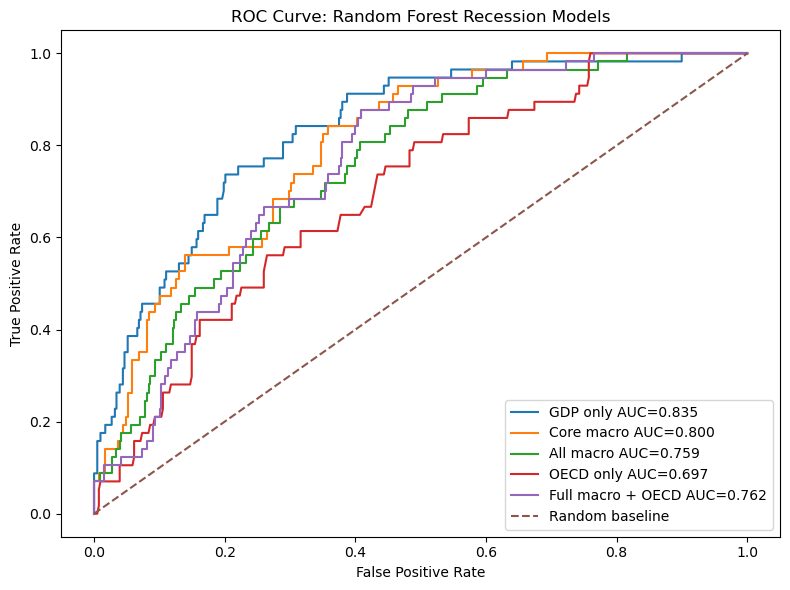

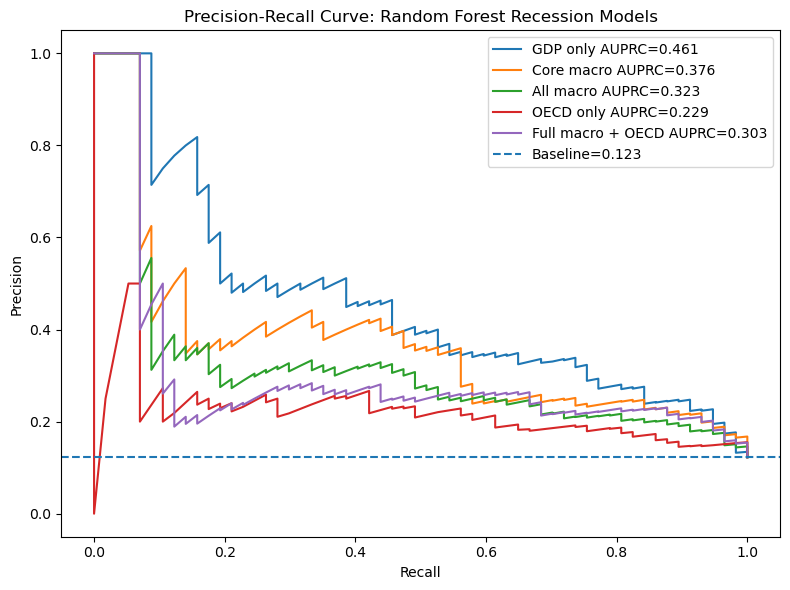

In [ ]:
# 7. ROC + Precision/Recall

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
)
import matplotlib.pyplot as plt

model_order = ["RF_A", "RF_B", "RF_C", "RF_D", "RF_E"]

# ROC curve
plt.figure(figsize=(8, 6))

for key in model_order:
    model = stored[key]["model"]
    X_test_model = stored[key]["X_test"]
    label = stored[key]["label"]

    y_prob = model.predict_proba(X_test_model)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"{label} AUC={auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Random Forest Recession Models")
plt.legend()
plt.tight_layout()
plt.show()


# Precision-Recall curve
plt.figure(figsize=(8, 6))

for key in model_order:
    model = stored[key]["model"]
    X_test_model = stored[key]["X_test"]
    label = stored[key]["label"]

    y_prob = model.predict_proba(X_test_model)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    auprc = average_precision_score(y_test, y_prob)

    plt.plot(recall, precision, label=f"{label} AUPRC={auprc:.3f}")

plt.axhline(y_test.mean(), linestyle="--", label=f"Baseline={y_test.mean():.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve: Random Forest Recession Models")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 8. Bootstrap AUC Values

from sklearn.metrics import roc_auc_score, brier_score_loss, average_precision_score
import numpy as np
import pandas as pd


def bootstrap_metric_ci(
    y_true, y_prob, metric_fn, n_bootstrap=1000, ci=95, random_state=42
):
    rng = np.random.default_rng(random_state)

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    n = len(y_true)

    boot_scores = []

    for _ in range(n_bootstrap):
        idx = rng.choice(np.arange(n), size=n, replace=True)

        y_sample = y_true[idx]
        prob_sample = y_prob[idx]

        if len(np.unique(y_sample)) < 2:
            continue

        boot_scores.append(metric_fn(y_sample, prob_sample))

    lower = np.percentile(boot_scores, (100 - ci) / 2)
    upper = np.percentile(boot_scores, 100 - (100 - ci) / 2)
    point = metric_fn(y_true, y_prob)

    return point, lower, upper


bootstrap_results = []

for key in ["RF_A", "RF_B", "RF_C", "RF_D", "RF_E"]:
    model = stored[key]["model"]
    X_test_model = stored[key]["X_test"]
    label = stored[key]["label"]

    y_prob = model.predict_proba(X_test_model)[:, 1]

    auc, auc_low, auc_high = bootstrap_metric_ci(y_test, y_prob, roc_auc_score)

    brier, brier_low, brier_high = bootstrap_metric_ci(y_test, y_prob, brier_score_loss)

    auprc, auprc_low, auprc_high = bootstrap_metric_ci(
        y_test, y_prob, average_precision_score
    )

    bootstrap_results.append(
        {
            "Model": label,
            "AUC": round(auc, 3),
            "AUC 95% CI": f"[{auc_low:.3f}, {auc_high:.3f}]",
            "Brier": round(brier, 3),
            "Brier 95% CI": f"[{brier_low:.3f}, {brier_high:.3f}]",
            "AUPRC": round(auprc, 3),
            "AUPRC 95% CI": f"[{auprc_low:.3f}, {auprc_high:.3f}]",
        }
    )

bootstrap_df = pd.DataFrame(bootstrap_results)
bootstrap_df.sort_values("AUC", ascending=False)

,Model,AUC,AUC 95% CI,Brier,Brier 95% CI,AUPRC,AUPRC 95% CI
0,GDP only,0.835,"[0.783, 0.882]",0.154,"[0.142, 0.167]",0.461,"[0.334, 0.587]"
1,Core macro,0.800,"[0.749, 0.848]",0.161,"[0.151, 0.171]",0.376,"[0.266, 0.502]"
4,Full macro + OECD,0.762,"[0.710, 0.814]",0.134,"[0.123, 0.146]",0.303,"[0.207, 0.409]"
2,All macro,0.759,"[0.698, 0.812]",0.112,"[0.098, 0.126]",0.323,"[0.221, 0.446]"
3,OECD only,0.697,"[0.629, 0.762]",0.202,"[0.186, 0.220]",0.229,"[0.159, 0.334]"


In [ ]:
# 9. Calibration Curve

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss,
    average_precision_score,
    log_loss,
)
import matplotlib.pyplot as plt

best_key = "RF_E"

base_model = stored[best_key]["model"]
X_val_best = stored[best_key]["X_val"]
X_test_best = stored[best_key]["X_test"]

# Calibrate using validation set only
calibrated_model = CalibratedClassifierCV(
    estimator=base_model, method="sigmoid", cv="prefit"
)

calibrated_model.fit(X_val_best, y_val)

# Compare before vs after
y_prob_raw = base_model.predict_proba(X_test_best)[:, 1]
y_prob_cal = calibrated_model.predict_proba(X_test_best)[:, 1]

print("Raw RF:")
print("AUC:", roc_auc_score(y_test, y_prob_raw))
print("Brier:", brier_score_loss(y_test, y_prob_raw))
print("AUPRC:", average_precision_score(y_test, y_prob_raw))
print("LogLoss:", log_loss(y_test, y_prob_raw))

print("\nCalibrated RF:")
print("AUC:", roc_auc_score(y_test, y_prob_cal))
print("Brier:", brier_score_loss(y_test, y_prob_cal))
print("AUPRC:", average_precision_score(y_test, y_prob_cal))
print("LogLoss:", log_loss(y_test, y_prob_cal))

Raw RF:
AUC: 0.762125902992776
Brier: 0.1339219771224541
AUPRC: 0.3031275739483359
LogLoss: 0.43036489980433457

Calibrated RF:
AUC: 0.762125902992776
Brier: 0.10048095341020662
AUPRC: 0.3031275739483359
LogLoss: 0.3333844847014582


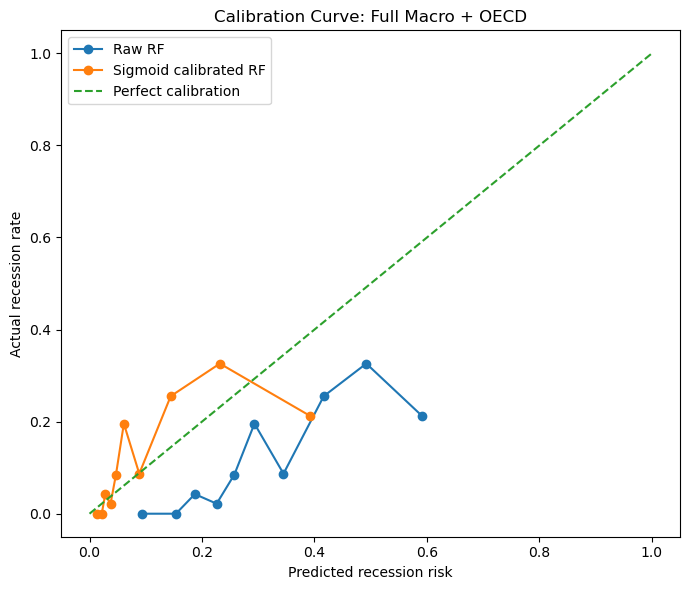

In [35]:
prob_true_raw, prob_pred_raw = calibration_curve(
    y_test, y_prob_raw, n_bins=10, strategy="quantile"
)

prob_true_cal, prob_pred_cal = calibration_curve(
    y_test, y_prob_cal, n_bins=10, strategy="quantile"
)

plt.figure(figsize=(7, 6))

plt.plot(prob_pred_raw, prob_true_raw, marker="o", label="Raw RF")
plt.plot(prob_pred_cal, prob_true_cal, marker="o", label="Sigmoid calibrated RF")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

plt.xlabel("Predicted recession risk")
plt.ylabel("Actual recession rate")
plt.title("Calibration Curve: Full Macro + OECD")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 10. Regional Income groups

# Income group mapping

high_income = {
    "Andorra",
    "Antigua and Barbuda",
    "Aruba",
    "Australia",
    "Austria",
    "Bahamas",
    "Bahrain",
    "Barbados",
    "Belgium",
    "Bermuda",
    "Brunei",
    "Canada",
    "Cayman Islands",
    "Chile",
    "Croatia",
    "Curacao",
    "Cyprus",
    "Czech Republic",
    "Denmark",
    "Estonia",
    "Faroe Islands",
    "Finland",
    "France",
    "French Polynesia",
    "Germany",
    "Greece",
    "Greenland",
    "Guam",
    "Hong Kong SAR",
    "Hungary",
    "Iceland",
    "Ireland",
    "Israel",
    "Italy",
    "Japan",
    "Korea, Rep.",
    "Kuwait",
    "Latvia",
    "Liechtenstein",
    "Lithuania",
    "Luxembourg",
    "Macao SAR",
    "Malta",
    "Mauritius",
    "Netherlands",
    "New Zealand",
    "Norway",
    "Oman",
    "Panama",
    "Poland",
    "Portugal",
    "Puerto Rico",
    "Qatar",
    "Romania",
    "San Marino",
    "Saudi Arabia",
    "Seychelles",
    "Singapore",
    "Slovakia",
    "Slovenia",
    "Spain",
    "Sweden",
    "Switzerland",
    "Trinidad and Tobago",
    "United Arab Emirates",
    "United Kingdom",
    "United States",
    "Uruguay",
}

upper_middle = {
    "Albania",
    "Algeria",
    "Argentina",
    "Armenia",
    "Azerbaijan",
    "Belarus",
    "Belize",
    "Bosnia and Herzegovina",
    "Botswana",
    "Brazil",
    "Bulgaria",
    "China",
    "Colombia",
    "Costa Rica",
    "Cuba",
    "Dominica",
    "Dominican Republic",
    "Ecuador",
    "Fiji",
    "Gabon",
    "Georgia",
    "Grenada",
    "Guatemala",
    "Indonesia",
    "Iran",
    "Iraq",
    "Jamaica",
    "Jordan",
    "Kazakhstan",
    "Kosovo",
    "Libya",
    "Malaysia",
    "Maldives",
    "Mexico",
    "Moldova",
    "Mongolia",
    "Montenegro",
    "North Macedonia",
    "Paraguay",
    "Peru",
    "Philippines",
    "Russia",
    "Samoa",
    "Serbia",
    "South Africa",
    "St. Lucia",
    "Suriname",
    "Thailand",
    "Tonga",
    "Turkiye",
    "Turkmenistan",
    "Venezuela",
    "West Bank and Gaza",
}

lower_middle = {
    "Angola",
    "Bangladesh",
    "Benin",
    "Bhutan",
    "Bolivia",
    "Cabo Verde",
    "Cambodia",
    "Cameroon",
    "Comoros",
    "Congo, Rep.",
    "Cote d'Ivoire",
    "Djibouti",
    "Egypt",
    "El Salvador",
    "Eswatini",
    "Ghana",
    "Guinea-Bissau",
    "Haiti",
    "Honduras",
    "India",
    "Kenya",
    "Kiribati",
    "Kyrgyzstan",
    "Laos",
    "Lebanon",
    "Lesotho",
    "Mauritania",
    "Micronesia, Fed. Sts.",
    "Morocco",
    "Myanmar",
    "Nepal",
    "Nicaragua",
    "Nigeria",
    "Pakistan",
    "Papua New Guinea",
    "Sao Tome and Principe",
    "Senegal",
    "Solomon Islands",
    "Sri Lanka",
    "Sudan",
    "Syria Arab Republic",
    "Tajikistan",
    "Tanzania",
    "Timor-Leste",
    "Togo",
    "Tunisia",
    "Ukraine",
    "Uzbekistan",
    "Vanuatu",
    "Viet Nam",
    "Zimbabwe",
}

low_income = {
    "Afghanistan",
    "Burkina Faso",
    "Burundi",
    "Central African Republic",
    "Chad",
    "Congo, Dem. Rep.",
    "Ethiopia",
    "Gambia",
    "Guinea",
    "Liberia",
    "Madagascar",
    "Malawi",
    "Mali",
    "Mozambique",
    "Niger",
    "Rwanda",
    "Sierra Leone",
    "Somalia",
    "South Sudan",
    "Uganda",
    "Zambia",
}


def get_income_group(country):
    if country in high_income:
        return "High income"
    elif country in upper_middle:
        return "Upper middle income"
    elif country in lower_middle:
        return "Lower middle income"
    elif country in low_income:
        return "Low income"
    else:
        return "Unclassified"

In [ ]:
test_df = test_df.copy()
test_df["income_group"] = test_df["country"].apply(get_income_group)

print(test_df["income_group"].value_counts())

print("\nUnclassified countries:")
print(
    sorted(test_df.loc[test_df["income_group"] == "Unclassified", "country"].unique())
)

income_group
High income            154
Upper middle income    126
Lower middle income    106
Low income              40
Unclassified            39
Name: count, dtype: int64

Unclassified countries:
['American Samoa', 'Andorra, Principality of', 'Equatorial Guinea', 'Guyana', 'Liechtenstein, Principality of', 'Marshall Islands', 'Namibia', 'Nauru', 'New Caledonia', 'Northern Mariana Islands', 'Palau', 'Sint Maarten (Dutch part)', 'Somalia, Fed. Rep.', 'St. Kitts and Nevis', 'St. Vincent and the Grenadines', 'Taiwan Province of China', 'Turks and Caicos Islands', 'Tuvalu', 'Venezuela, República Bolivariana de', 'Virgin Islands (U.S.)', 'Yemen']


In [ ]:
income_group_name_map = {
    "Andorra, Principality of": "Andorra",
    "Liechtenstein, Principality of": "Liechtenstein",
    "Somalia, Fed. Rep.": "Somalia",
    "Venezuela, República Bolivariana de": "Venezuela",
}

test_df["country_clean"] = test_df["country"].replace(income_group_name_map)

# Add missing countries to groups
high_income.update(
    {
        "American Samoa",
        "Andorra",
        "Liechtenstein",
        "Nauru",
        "New Caledonia",
        "Northern Mariana Islands",
        "Palau",
        "Sint Maarten (Dutch part)",
        "St. Kitts and Nevis",
        "Turks and Caicos Islands",
        "Virgin Islands (U.S.)",
    }
)

upper_middle.update(
    {
        "Equatorial Guinea",
        "Guyana",
        "Marshall Islands",
        "Namibia",
        "St. Vincent and the Grenadines",
        "Taiwan Province of China",
        "Venezuela",
    }
)

low_income.update({"Somalia", "Tuvalu", "Yemen"})

test_df["income_group"] = test_df["country_clean"].apply(get_income_group)

print(test_df["income_group"].value_counts())

print("\nStill unclassified:")
print(
    sorted(test_df.loc[test_df["income_group"] == "Unclassified", "country"].unique())
)

income_group
High income            175
Upper middle income    139
Lower middle income    106
Low income              45
Name: count, dtype: int64

Still unclassified:
[]


In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score, brier_score_loss, average_precision_score

# Use the final calibrated model
model = calibrated_model  # sigmoid RF
X_test_best = stored["RF_E"]["X_test"]  # Full macro + OECD

y_prob = model.predict_proba(X_test_best)[:, 1]

test_df_eval = test_df.copy()
test_df_eval["y_true"] = y_test.values
test_df_eval["y_prob"] = y_prob


def bootstrap_auc_ci(df, n_boot=1000, seed=42):
    """
    Bootstrap 95% confidence interval for AUC.
    Skips bootstrap samples that do not contain both classes.
    """
    rng = np.random.default_rng(seed)
    aucs = []

    y_true = df["y_true"].values
    y_prob = df["y_prob"].values
    n = len(df)

    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        y_sample = y_true[idx]
        p_sample = y_prob[idx]

        # AUC needs both recession and non-recession cases
        if len(np.unique(y_sample)) < 2:
            continue

        aucs.append(roc_auc_score(y_sample, p_sample))

    if len(aucs) == 0:
        return np.nan, np.nan

    lower = np.percentile(aucs, 2.5)
    upper = np.percentile(aucs, 97.5)

    return lower, upper


results = []

for group in test_df_eval["income_group"].dropna().unique():
    df_g = test_df_eval[test_df_eval["income_group"] == group].copy()

    # Skip groups with no class variation
    if len(df_g["y_true"].unique()) < 2:
        continue

    auc = roc_auc_score(df_g["y_true"], df_g["y_prob"])
    brier = brier_score_loss(df_g["y_true"], df_g["y_prob"])
    auprc = average_precision_score(df_g["y_true"], df_g["y_prob"])

    auc_ci_low, auc_ci_high = bootstrap_auc_ci(df_g, n_boot=1000, seed=42)

    results.append(
        {
            "income_group": group,
            "n": len(df_g),
            "recessions": int(df_g["y_true"].sum()),
            "AUC": auc,
            "AUC 95% CI Lower": auc_ci_low,
            "AUC 95% CI Upper": auc_ci_high,
            "AUC 95% CI": f"[{auc_ci_low:.3f}, {auc_ci_high:.3f}]",
            "Brier": brier,
            "AUPRC": auprc,
        }
    )

income_results = pd.DataFrame(results).sort_values("AUC", ascending=False)

income_results

NameError: name 'calibrated_model' is not defined

In [43]:
test_df_eval.groupby("income_group")["y_true"].agg(["count", "sum", "mean"])

,count,sum,mean
income_group,,,
High income,175,21,0.120000
Low income,45,3,0.066667
Lower middle income,106,16,0.150943
Upper middle income,139,17,0.122302


In [ ]:
# 11. Error Cost Threshold table

from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

# Final calibrated model probabilities
y_prob_final = calibrated_model.predict_proba(stored["RF_E"]["X_test"])[:, 1]

thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]

threshold_rows = []

for threshold in thresholds:
    y_pred = (y_prob_final >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    false_alarm_rate = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    missed_recession_rate = fn / (tp + fn) if (tp + fn) > 0 else np.nan

    threshold_rows.append(
        {
            "threshold": threshold,
            "true_positives": tp,
            "false_alarms": fp,
            "missed_recessions": fn,
            "true_negatives": tn,
            "recall": recall,
            "precision": precision,
            "false_alarm_rate": false_alarm_rate,
            "missed_recession_rate": missed_recession_rate,
        }
    )

threshold_df = pd.DataFrame(threshold_rows)

threshold_df

,threshold,true_positives,false_alarms,missed_recessions,true_negatives,recall,precision,false_alarm_rate,missed_recession_rate
0,0.05,51,192,6,216,0.894737,0.209877,0.470588,0.105263
1,0.10,38,109,19,299,0.666667,0.258503,0.267157,0.333333
2,0.15,28,85,29,323,0.491228,0.247788,0.208333,0.508772
3,0.20,21,59,36,349,0.368421,0.262500,0.144608,0.631579
4,0.25,17,46,40,362,0.298246,0.269841,0.112745,0.701754
5,0.30,9,36,48,372,0.157895,0.200000,0.088235,0.842105
6,0.35,7,19,50,389,0.122807,0.269231,0.046569,0.877193
7,0.40,6,8,51,400,0.105263,0.428571,0.019608,0.894737


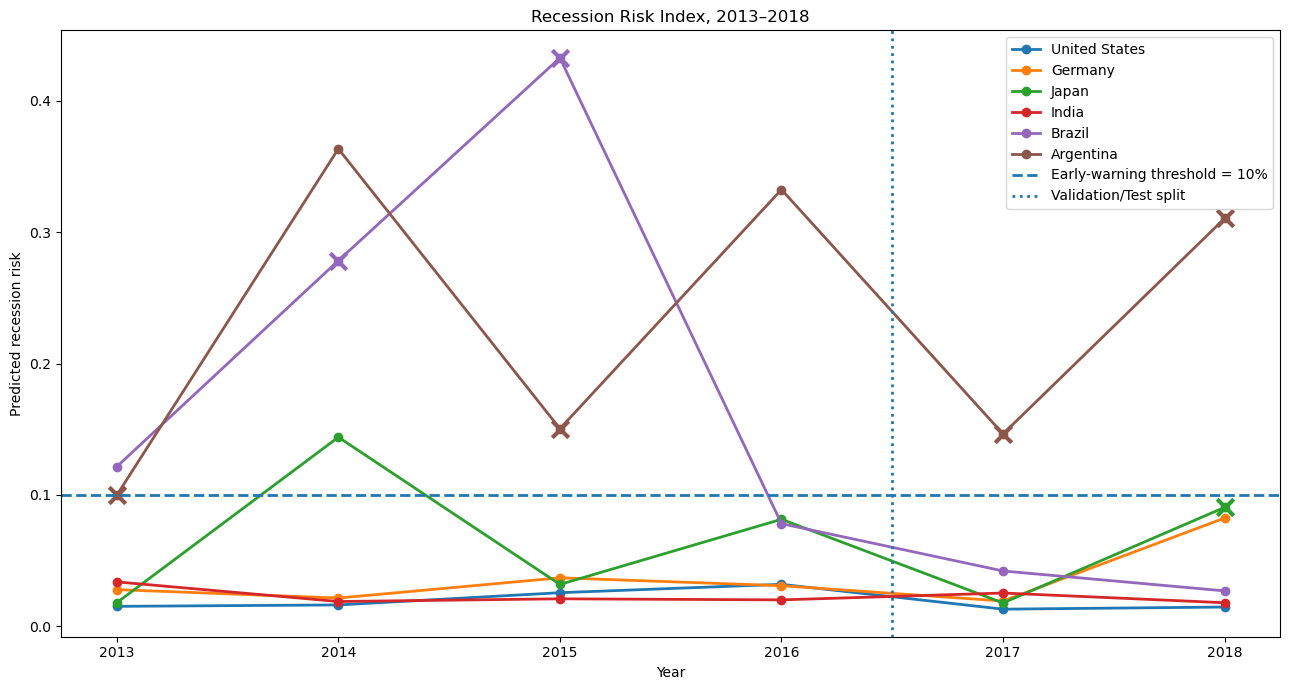

In [ ]:
# 12. Recession Index Plot

# Recession index plot over validation + test window: 2013–2018

plot_countries = ["United States", "Germany", "Japan", "India", "Brazil", "Argentina"]

# Get probabilities for validation and test using calibrated model
y_prob_val = calibrated_model.predict_proba(stored["RF_E"]["X_val"])[:, 1]
y_prob_test = calibrated_model.predict_proba(stored["RF_E"]["X_test"])[:, 1]

val_plot_df = val_df.copy()
val_plot_df["predicted_recession_risk"] = y_prob_val
val_plot_df["actual_recession_next_year"] = y_val.values
val_plot_df["split"] = "Validation"

test_plot_df = test_df.copy()
test_plot_df["predicted_recession_risk"] = y_prob_test
test_plot_df["actual_recession_next_year"] = y_test.values
test_plot_df["split"] = "Test"

index_plot_df = pd.concat([val_plot_df, test_plot_df], ignore_index=True)
index_plot_df = index_plot_df[index_plot_df["country"].isin(plot_countries)].copy()

plt.figure(figsize=(13, 7))

for country in plot_countries:
    country_df = index_plot_df[index_plot_df["country"] == country].sort_values("year")

    plt.plot(
        country_df["year"],
        country_df["predicted_recession_risk"],
        marker="o",
        linewidth=2,
        label=country,
    )

    recession_points = country_df[country_df["actual_recession_next_year"] == 1]

    plt.scatter(
        recession_points["year"],
        recession_points["predicted_recession_risk"],
        marker="x",
        s=140,
        linewidths=3,
    )

plt.axhline(0.10, linestyle="--", linewidth=2, label="Early-warning threshold = 10%")
plt.axvline(2016.5, linestyle=":", linewidth=2, label="Validation/Test split")

plt.xlabel("Year")
plt.ylabel("Predicted recession risk")
plt.title("Recession Risk Index, 2013–2018")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 13. COVID Stress Test

# COVID stress test: 2019–2022

covid_df = world_bank[
    (world_bank["year"] >= 2019) & (world_bank["year"] <= 2022)
].copy()

y_covid = covid_df["recession_next_year"]

_, _, X_covid = prepare_features(
    train_df, val_df, covid_df, FULL_COLS, include_country=True
)

y_prob_covid = calibrated_model.predict_proba(X_covid)[:, 1]

covid_metrics = {
    "AUC": roc_auc_score(y_covid, y_prob_covid),
    "Brier": brier_score_loss(y_covid, y_prob_covid),
    "AUPRC": average_precision_score(y_covid, y_prob_covid),
    "Recession rate": y_covid.mean(),
    "N": len(covid_df),
}

covid_metrics

{'AUC': 0.5537966368891224,
 'Brier': 0.2033906422137884,
 'AUPRC': 0.30310780357960126,
 'Recession rate': 0.2502708559046587,
 'N': 923}

In [ ]:
pd.DataFrame(
    [
        {
            "Evaluation": "Normal test window (2017–2018)",
            "AUC": roc_auc_score(y_test, y_prob_final),
            "Brier": brier_score_loss(y_test, y_prob_final),
            "AUPRC": average_precision_score(y_test, y_prob_final),
            "Recession rate": y_test.mean(),
            "N": len(test_df),
        },
        {
            "Evaluation": "COVID stress test (2019–2022)",
            "AUC": covid_metrics["AUC"],
            "Brier": covid_metrics["Brier"],
            "AUPRC": covid_metrics["AUPRC"],
            "Recession rate": covid_metrics["Recession rate"],
            "N": covid_metrics["N"],
        },
    ]
)

,Evaluation,AUC,Brier,AUPRC,Recession rate,N
0,Normal test window (2017–2018),0.762126,0.100481,0.303128,0.122581,465
1,COVID stress test (2019–2022),0.553797,0.203391,0.303108,0.250271,923
